# 3. Bi-TCN IBM Training

Notebook này tái tạo mô hình **Bidirectional Temporal Convolutional Network (Bi-TCN)** cho bài toán dự đoán nghỉ việc trên IBM HR Analytics, đồng thời thêm các cải tiến nhẹ để giảm overfitting trên bộ dữ liệu nhỏ:

- 5-fold stratified cross-validation
- Augmentation chỉ trên train fold
- Bi-TCN hai nhánh theo paper: kernel 3/dilation 1 và kernel 5/dilation 2
- Forward/backward temporal branches bằng `torch.flip`
- Residual causal convolutions, BatchNorm, channel attention, global average pooling
- AdamW, weight decay, ReduceLROnPlateau, early stopping, threshold optimization

Mục tiêu chính là tái tạo kiến trúc paper một cách trung thực, sau đó cải thiện tính ổn định/generalization cho IBM.


## 1. Project Setup


In [27]:
import importlib.util
import sys

REQUIRED_PACKAGES = {
    "torch": "torch",
    "sklearn": "scikit-learn",
    "imblearn": "imbalanced-learn",
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "seaborn": "seaborn",
    "tqdm": "tqdm",
}
missing_packages = [
    pip_name for import_name, pip_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(import_name) is None
]
if missing_packages:
    print("Missing packages:", ", ".join(missing_packages))
    print("Install in this notebook environment with:")
    print("%pip install " + " ".join(missing_packages))
    raise ImportError("Install the missing packages above, then restart the kernel and rerun this notebook.")

import copy
import json
import math
import os
import random
import time
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

try:
    from imblearn.over_sampling import ADASYN, RandomOverSampler, SMOTE
    IMBLEARN_AVAILABLE = True
except ImportError:
    IMBLEARN_AVAILABLE = False
    ADASYN = RandomOverSampler = SMOTE = None
    print("imbalanced-learn is not installed. The notebook will fall back to RAW training.")

def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data" / "processed" / "IBM_Cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate data/processed/IBM_Cleaned.csv from the current directory.")

PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "IBM_Cleaned.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "bitcn_ibm"
MODEL_DIR = OUTPUT_DIR / "models"
FIGURE_DIR = OUTPUT_DIR / "figures"
LOG_DIR = OUTPUT_DIR / "logs"

for path in [OUTPUT_DIR, MODEL_DIR, FIGURE_DIR, LOG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

@dataclass
class Config:
    seed: int = 42
    n_splits: int = 5
    target_col: str = "Attrition"
    # Run all candidates, then select the best augmentation by mean CV F1.
    augmentation_candidates: tuple[str, ...] = ("GAN", "SMOTE", "RandomOverSampling", "ADASYN", "RAW")
    batch_size: int = 32
    epochs: int = 160
    patience: int = 28
    lr: float = 7e-4
    weight_decay: float = 5e-5
    input_noise_std: float = 0.015
    dropout: float = 0.40
    stem_channels: int = 16
    filters_1: int = 32
    filters_2: int = 64
    hidden_dim: int = 96
    attention_reduction: int = 8
    label_smoothing: float = 0.00
    num_workers: int = 0
    threshold_metric: str = "f1"
    selection_metric: str = "f1"
    use_amp: bool = True
    use_focal_loss: bool = False
    focal_gamma: float = 2.0
    gan_latent_dim: int = 32
    gan_hidden_dim: int = 128
    gan_epochs: int = 600
    gan_batch_size: int = 32
    gan_lr: float = 2e-4
    gan_weight_decay: float = 1e-5

CFG = Config()

def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass

seed_everything(CFG.seed)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"
AMP_ENABLED = CFG.use_amp and DEVICE.type == "cuda"

print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {DEVICE}")
print(f"AMP enabled: {AMP_ENABLED}")
print(json.dumps(asdict(CFG), indent=2))

with open(OUTPUT_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(asdict(CFG), f, indent=2)


Project root: F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN
Device: cpu
AMP enabled: False
{
  "seed": 42,
  "n_splits": 5,
  "target_col": "Attrition",
  "augmentation_candidates": [
    "GAN",
    "SMOTE",
    "RandomOverSampling",
    "ADASYN",
    "RAW"
  ],
  "batch_size": 32,
  "epochs": 160,
  "patience": 28,
  "lr": 0.0007,
  "weight_decay": 5e-05,
  "input_noise_std": 0.015,
  "dropout": 0.4,
  "stem_channels": 16,
  "filters_1": 32,
  "filters_2": 64,
  "hidden_dim": 96,
  "attention_reduction": 8,
  "label_smoothing": 0.0,
  "num_workers": 0,
  "threshold_metric": "f1",
  "selection_metric": "f1",
  "use_amp": true,
  "use_focal_loss": false,
  "focal_gamma": 2.0,
  "gan_latent_dim": 32,
  "gan_hidden_dim": 128,
  "gan_epochs": 600,
  "gan_batch_size": 32,
  "gan_lr": 0.0002,
  "gan_weight_decay": 1e-05
}


## 2. Load Dataset


In [28]:
df = pd.read_csv(DATA_PATH)

if CFG.target_col not in df.columns:
    raise ValueError(f"Expected target column '{CFG.target_col}', found: {list(df.columns)}")

print("Dataset shape:", df.shape)
print("\nMissing values:", int(df.isna().sum().sum()))
print("Duplicated rows:", int(df.duplicated().sum()))
print("\nClass distribution:")
print(df[CFG.target_col].value_counts().sort_index())
print("\nClass ratio:")
print((df[CFG.target_col].value_counts(normalize=True).sort_index() * 100).round(2).astype(str) + "%")

display(df.head())


Dataset shape: (1470, 44)

Missing values: 0
Duplicated rows: 0

Class distribution:
Attrition
0    1233
1     237
Name: count, dtype: int64

Class ratio:
Attrition
0    83.88%
1    16.12%
Name: proportion, dtype: str


,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,0.547619,1,0.5,0.715820,0.000000,0.25,0.333333,0.0,0.914286,0.666667,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.738095,0,1.0,0.126700,0.250000,0.00,0.666667,1.0,0.442857,0.333333,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.452381,1,0.5,0.909807,0.035714,0.25,1.000000,1.0,0.885714,0.333333,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.357143,0,1.0,0.923407,0.071429,0.75,1.000000,0.0,0.371429,0.666667,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.214286,0,0.5,0.350036,0.035714,0.00,0.000000,1.0,0.142857,0.666667,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## 3. Feature / Target Split


In [29]:
X_df = df.drop(columns=[CFG.target_col]).copy()
y = df[CFG.target_col].astype(int).to_numpy()

if not set(np.unique(y)).issubset({0, 1}):
    raise ValueError("Attrition target must be binary encoded as 0/1.")

feature_names = X_df.columns.tolist()
X_raw = X_df.astype("float32").to_numpy()

print(f"Number of samples: {X_raw.shape[0]}")
print(f"Number of features / TCN sequence length: {X_raw.shape[1]}")
print("Expected TCN input after fold preprocessing: (batch, 1, num_features)")


Number of samples: 1470
Number of features / TCN sequence length: 43
Expected TCN input after fold preprocessing: (batch, 1, num_features)


## 4. Cross-Validation Helpers and Augmentation


In [30]:
class TabularGenerator(nn.Module):
    def __init__(self, latent_dim: int, output_dim: int, hidden_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid(),
        )

    def forward(self, z):
        return self.net(z)


class TabularDiscriminator(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.25),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.25),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, x):
        return self.net(x)


def gan_augment_minority(X_train_2d: np.ndarray, y_train: np.ndarray, fold: int):
    class_counts = dict(zip(*np.unique(y_train, return_counts=True)))
    minority_class = min(class_counts, key=class_counts.get)
    majority_class = max(class_counts, key=class_counts.get)
    n_to_generate = class_counts[majority_class] - class_counts[minority_class]

    if n_to_generate <= 0:
        print("GAN skipped because classes are already balanced:", class_counts)
        return X_train_2d, y_train

    seed_everything(CFG.seed + 10_000 + fold)
    real_minority = X_train_2d[y_train == minority_class].astype("float32")
    feature_dim = real_minority.shape[1]

    generator = TabularGenerator(CFG.gan_latent_dim, feature_dim, CFG.gan_hidden_dim).to(DEVICE)
    discriminator = TabularDiscriminator(feature_dim, CFG.gan_hidden_dim).to(DEVICE)
    opt_g = torch.optim.AdamW(generator.parameters(), lr=CFG.gan_lr, betas=(0.5, 0.999), weight_decay=CFG.gan_weight_decay)
    opt_d = torch.optim.AdamW(discriminator.parameters(), lr=CFG.gan_lr, betas=(0.5, 0.999), weight_decay=CFG.gan_weight_decay)
    criterion = nn.BCEWithLogitsLoss()

    minority_loader = DataLoader(
        TensorDataset(torch.tensor(real_minority, dtype=torch.float32)),
        batch_size=min(CFG.gan_batch_size, len(real_minority)),
        shuffle=True,
        drop_last=False,
    )

    generator.train()
    discriminator.train()
    for epoch in range(1, CFG.gan_epochs + 1):
        d_losses, g_losses = [], []
        for (real_batch,) in minority_loader:
            real_batch = real_batch.to(DEVICE)
            batch_size = real_batch.size(0)

            real_targets = torch.empty(batch_size, 1, device=DEVICE).uniform_(0.85, 1.0)
            fake_targets = torch.empty(batch_size, 1, device=DEVICE).uniform_(0.0, 0.15)

            z = torch.randn(batch_size, CFG.gan_latent_dim, device=DEVICE)
            fake_batch = generator(z).detach()
            real_batch_noisy = torch.clamp(real_batch + 0.01 * torch.randn_like(real_batch), 0.0, 1.0)

            opt_d.zero_grad(set_to_none=True)
            d_real = criterion(discriminator(real_batch_noisy), real_targets)
            d_fake = criterion(discriminator(fake_batch), fake_targets)
            d_loss = d_real + d_fake
            d_loss.backward()
            opt_d.step()

            z = torch.randn(batch_size, CFG.gan_latent_dim, device=DEVICE)
            opt_g.zero_grad(set_to_none=True)
            generated = generator(z)
            g_loss = criterion(discriminator(generated), torch.ones(batch_size, 1, device=DEVICE))
            g_loss.backward()
            opt_g.step()

            d_losses.append(float(d_loss.detach().cpu()))
            g_losses.append(float(g_loss.detach().cpu()))

        if epoch in {1, CFG.gan_epochs} or epoch % 100 == 0:
            print(f"GAN fold {fold} epoch {epoch:03d}/{CFG.gan_epochs} | D={np.mean(d_losses):.4f} | G={np.mean(g_losses):.4f}")

    generator.eval()
    generated_batches = []
    remaining = n_to_generate
    with torch.no_grad():
        while remaining > 0:
            current = min(CFG.gan_batch_size, remaining)
            z = torch.randn(current, CFG.gan_latent_dim, device=DEVICE)
            generated_batches.append(generator(z).cpu().numpy())
            remaining -= current

    X_generated = np.vstack(generated_batches).astype("float32")
    X_generated = np.clip(X_generated, 0.0, 1.0)
    y_generated = np.full(n_to_generate, minority_class, dtype=int)

    X_aug = np.vstack([X_train_2d, X_generated]).astype("float32")
    y_aug = np.concatenate([y_train, y_generated]).astype(int)
    order = np.random.default_rng(CFG.seed + fold).permutation(len(y_aug))
    print("GAN training distribution:", dict(zip(*np.unique(y_aug, return_counts=True))))
    return X_aug[order], y_aug[order]


def make_sampler(name: str, seed: int):
    name = name.lower()
    if name in {"raw", "none", "no"}:
        return None
    if not IMBLEARN_AVAILABLE:
        print("imbalanced-learn unavailable; using RAW training for this fold.")
        return None
    if name in {"randomoversampling", "random_over_sampling", "ros"}:
        return RandomOverSampler(random_state=seed)
    if name == "smote":
        return SMOTE(random_state=seed, k_neighbors=5)
    if name == "adasyn":
        return ADASYN(random_state=seed, n_neighbors=5)
    raise ValueError(f"Unknown augmentation: {name}")

def augment_training_data(X_train_2d: np.ndarray, y_train: np.ndarray, fold: int, augmentation: str):
    if augmentation.lower() == "gan":
        return gan_augment_minority(X_train_2d, y_train, fold)

    sampler = make_sampler(augmentation, CFG.seed + fold)
    if sampler is None:
        print("Training distribution without augmentation:", dict(zip(*np.unique(y_train, return_counts=True))))
        return X_train_2d, y_train
    X_aug, y_aug = sampler.fit_resample(X_train_2d, y_train)
    print(f"{augmentation} training distribution:", dict(zip(*np.unique(y_aug, return_counts=True))))
    return X_aug.astype("float32"), y_aug.astype(int)

def to_tcn_tensor(X_2d: np.ndarray) -> torch.Tensor:
    return torch.tensor(X_2d.reshape(X_2d.shape[0], 1, X_2d.shape[1]), dtype=torch.float32)

def make_loader(X_2d: np.ndarray, y_1d: np.ndarray, train: bool) -> DataLoader:
    dataset = TensorDataset(
        to_tcn_tensor(X_2d),
        torch.tensor(y_1d.reshape(-1, 1), dtype=torch.float32),
    )
    return DataLoader(
        dataset,
        batch_size=CFG.batch_size,
        shuffle=train,
        num_workers=CFG.num_workers,
        pin_memory=PIN_MEMORY,
        drop_last=False,
    )


## 5. Metrics and Threshold Optimization


In [31]:
def find_best_threshold(y_true: np.ndarray, y_prob: np.ndarray, metric: str = "f1"):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    if len(thresholds) == 0:
        return 0.5, 0.0

    precision = precision[:-1]
    recall = recall[:-1]
    eps = 1e-12

    if metric == "f2":
        beta2 = 4.0
        scores = (1 + beta2) * precision * recall / (beta2 * precision + recall + eps)
    else:
        scores = 2 * precision * recall / (precision + recall + eps)

    best_idx = int(np.nanargmax(scores))
    return float(thresholds[best_idx]), float(scores[best_idx])

def compute_metrics(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> dict:
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else np.nan,
        "pr_auc": average_precision_score(y_true, y_prob),
        "threshold": threshold,
    }
    return metrics

def summarize_metrics(rows: list[dict]) -> pd.DataFrame:
    df_metrics = pd.DataFrame(rows)
    metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "threshold", "best_epoch"]
    summary = df_metrics[metric_cols].agg(["mean", "std"]).T
    summary["mean_std"] = summary.apply(lambda r: f"{r['mean']:.4f} +/- {r['std']:.4f}", axis=1)
    return summary


## 6. Bi-TCN Architecture


In [32]:
class Chomp1d(nn.Module):
    def __init__(self, chomp_size: int):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        if self.chomp_size == 0:
            return x
        return x[:, :, :-self.chomp_size].contiguous()


class TemporalBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int, dilation: int, dropout: float):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(out_channels, out_channels, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        self.final_relu = nn.ReLU()

    def forward(self, x):
        return self.final_relu(self.net(x) + self.downsample(x))


class TemporalConvNet(nn.Module):
    def __init__(self, in_channels: int, channels: list[int], kernel_size: int, dilation: int, dropout: float):
        super().__init__()
        layers = []
        current_channels = in_channels
        for out_channels in channels:
            layers.append(
                TemporalBlock(
                    in_channels=current_channels,
                    out_channels=out_channels,
                    kernel_size=kernel_size,
                    dilation=dilation,
                    dropout=dropout,
                )
            )
            current_channels = out_channels
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


class ChannelAttention(nn.Module):
    def __init__(self, channels: int, reduction: int = 8):
        super().__init__()
        hidden = max(1, channels // reduction)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, hidden),
            nn.ReLU(),
            nn.Linear(hidden, channels),
            nn.Sigmoid(),
        )

    def forward(self, x):
        weights = self.pool(x).squeeze(-1)
        weights = self.fc(weights).unsqueeze(-1)
        return x * weights


class GaussianNoise(nn.Module):
    def __init__(self, std: float = 0.0):
        super().__init__()
        self.std = std

    def forward(self, x):
        if self.training and self.std > 0:
            return x + torch.randn_like(x) * self.std
        return x


class BiTCNClassifier(nn.Module):
    def __init__(
        self,
        in_channels: int = 1,
        stem_channels: int = 16,
        filters_1: int = 32,
        filters_2: int = 64,
        hidden_dim: int = 96,
        dropout: float = 0.4,
        input_noise_std: float = 0.015,
        attention_reduction: int = 8,
    ):
        super().__init__()
        self.input_noise = GaussianNoise(input_noise_std)
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, stem_channels, kernel_size=1),
            nn.BatchNorm1d(stem_channels),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
        )
        # Paper branch 1: kernel=3, dilation=1. Paper branch 2: kernel=5, dilation=2.
        # Two residual blocks per paper stage give the model enough capacity on IBM's 43-feature sequence.
        self.forward_k3 = TemporalConvNet(stem_channels, [filters_1, filters_1], kernel_size=3, dilation=1, dropout=dropout)
        self.backward_k3 = TemporalConvNet(stem_channels, [filters_1, filters_1], kernel_size=3, dilation=1, dropout=dropout)
        self.forward_k5 = TemporalConvNet(filters_1 * 2, [filters_2, filters_2], kernel_size=5, dilation=2, dropout=dropout)
        self.backward_k5 = TemporalConvNet(filters_1 * 2, [filters_2, filters_2], kernel_size=5, dilation=2, dropout=dropout)

        merged_channels = filters_2 * 2
        self.attention = ChannelAttention(merged_channels, reduction=attention_reduction)
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.max_pool = nn.AdaptiveMaxPool1d(1)
        self.classifier = nn.Sequential(
            nn.Linear(merged_channels * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, x):
        x = self.input_noise(x)
        x = self.stem(x)
        x_rev = torch.flip(x, dims=[-1])
        f1 = self.forward_k3(x)
        b1 = torch.flip(self.backward_k3(x_rev), dims=[-1])
        stage1 = torch.cat([f1, b1], dim=1)

        stage1_rev = torch.flip(stage1, dims=[-1])
        f2 = self.forward_k5(stage1)
        b2 = torch.flip(self.backward_k5(stage1_rev), dims=[-1])
        features = torch.cat([f2, b2], dim=1)

        features = self.attention(features)
        pooled = torch.cat(
            [self.avg_pool(features).squeeze(-1), self.max_pool(features).squeeze(-1)],
            dim=1,
        )
        return self.classifier(pooled)


class FocalLossWithLogits(nn.Module):
    def __init__(self, alpha: float = 0.5, gamma: float = 2.0, label_smoothing: float = 0.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        if self.label_smoothing > 0:
            targets = targets * (1 - self.label_smoothing) + 0.5 * self.label_smoothing
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)
        pt = torch.where(targets >= 0.5, probs, 1 - probs)
        focal_weight = (1 - pt).pow(self.gamma)
        alpha_weight = torch.where(targets >= 0.5, self.alpha, 1 - self.alpha)
        return (alpha_weight * focal_weight * bce).mean()


def make_model() -> BiTCNClassifier:
    return BiTCNClassifier(
        in_channels=1,
        stem_channels=CFG.stem_channels,
        filters_1=CFG.filters_1,
        filters_2=CFG.filters_2,
        hidden_dim=CFG.hidden_dim,
        dropout=CFG.dropout,
        input_noise_std=CFG.input_noise_std,
        attention_reduction=CFG.attention_reduction,
    ).to(DEVICE)

model_preview = make_model()
n_params = sum(p.numel() for p in model_preview.parameters() if p.requires_grad)
print(model_preview)
print(f"Trainable parameters: {n_params:,}")
del model_preview


BiTCNClassifier(
  (input_noise): GaussianNoise()
  (stem): Sequential(
    (0): Conv1d(1, 16, kernel_size=(1,), stride=(1,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.2, inplace=False)
  )
  (forward_k3): TemporalConvNet(
    (network): Sequential(
      (0): TemporalBlock(
        (net): Sequential(
          (0): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(2,))
          (1): Chomp1d()
          (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (3): ReLU()
          (4): Dropout(p=0.4, inplace=False)
          (5): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(2,))
          (6): Chomp1d()
          (7): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (8): ReLU()
          (9): Dropout(p=0.4, inplace=False)
        )
        (downsample): Conv1d

## 7. Training and Evaluation Functions


In [33]:
def make_loss(y_train: np.ndarray):
    positives = float(np.sum(y_train == 1))
    negatives = float(np.sum(y_train == 0))
    pos_weight_value = negatives / max(positives, 1.0)
    if CFG.use_focal_loss:
        alpha = negatives / max(positives + negatives, 1.0)
        criterion = FocalLossWithLogits(alpha=alpha, gamma=CFG.focal_gamma, label_smoothing=CFG.label_smoothing)
    else:
        pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    return criterion, pos_weight_value

def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    running_loss = 0.0
    all_probs, all_targets = [], []

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
            logits = model(xb)
            loss = criterion(logits, yb)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * xb.size(0)
        all_probs.append(torch.sigmoid(logits.detach()).cpu().numpy().ravel())
        all_targets.append(yb.detach().cpu().numpy().ravel())

    y_prob = np.concatenate(all_probs)
    y_true = np.concatenate(all_targets).astype(int)
    threshold, _ = find_best_threshold(y_true, y_prob, CFG.threshold_metric)
    metrics = compute_metrics(y_true, y_prob, threshold)
    metrics["loss"] = running_loss / len(loader.dataset)
    return metrics

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_probs, all_targets = [], []

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        running_loss += loss.item() * xb.size(0)
        all_probs.append(torch.sigmoid(logits).cpu().numpy().ravel())
        all_targets.append(yb.cpu().numpy().ravel())

    y_prob = np.concatenate(all_probs)
    y_true = np.concatenate(all_targets).astype(int)
    threshold, best_score = find_best_threshold(y_true, y_prob, CFG.threshold_metric)
    metrics = compute_metrics(y_true, y_prob, threshold)
    metrics["loss"] = running_loss / len(loader.dataset)
    metrics["threshold_score"] = best_score
    return metrics, y_true, y_prob

def save_fold_artifacts(augmentation: str, fold: int, y_true: np.ndarray, y_prob: np.ndarray, threshold: float):
    y_pred = (y_prob >= threshold).astype(int)
    run_name = augmentation.lower().replace(" ", "_")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4.8, 4.2))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["No Attrition", "Attrition"], yticklabels=["No Attrition", "Attrition"])
    plt.title(f"{augmentation} Fold {fold} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{run_name}_fold_{fold}_confusion_matrix.png", dpi=300)
    plt.close()

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    precision, recall, _ = precision_recall_curve(y_true, y_prob)

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_true, y_prob):.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{augmentation} Fold {fold} ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{run_name}_fold_{fold}_roc_curve.png", dpi=300)
    plt.close()

    plt.figure(figsize=(5, 4))
    plt.plot(recall, precision, label=f"PR-AUC = {average_precision_score(y_true, y_prob):.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{augmentation} Fold {fold} Precision-Recall Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{run_name}_fold_{fold}_pr_curve.png", dpi=300)
    plt.close()

    report = classification_report(y_true, y_pred, target_names=["No Attrition", "Attrition"], zero_division=0)
    with open(LOG_DIR / f"{run_name}_fold_{fold}_classification_report.txt", "w", encoding="utf-8") as f:
        f.write(report)


## 8. 5-Fold Cross-Validation Training


In [34]:
skf = StratifiedKFold(n_splits=CFG.n_splits, shuffle=True, random_state=CFG.seed)

def run_cv_for_augmentation(augmentation: str):
    run_name = augmentation.lower().replace(" ", "_")
    fold_results = []
    histories = {}
    oof_probs = np.zeros(len(y), dtype=np.float32)
    oof_thresholds = np.zeros(CFG.n_splits, dtype=np.float32)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_raw, y), start=1):
        print(f"\n{'=' * 16} {augmentation} | Fold {fold}/{CFG.n_splits} {'=' * 16}")
        seed_everything(CFG.seed + fold)

        X_train_raw, X_val_raw = X_raw[train_idx], X_raw[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Fit preprocessing only on the train fold. IBM_Cleaned is already scaled,
        # but fold-local MinMaxScaler prevents leakage if the source notebook changes later.
        scaler_preprocess = MinMaxScaler()
        X_train = scaler_preprocess.fit_transform(X_train_raw).astype("float32")
        X_val = scaler_preprocess.transform(X_val_raw).astype("float32")

        X_train_aug, y_train_aug = augment_training_data(X_train, y_train, fold, augmentation)

        train_loader = make_loader(X_train_aug, y_train_aug, train=True)
        val_loader = make_loader(X_val, y_val, train=False)

        model = make_model()
        criterion, pos_weight_value = make_loss(y_train_aug)
        optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="max", factor=0.5, patience=6, min_lr=1e-6
        )
        amp_scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

        best_state = None
        best_metrics = None
        best_epoch = 0
        best_score = -np.inf
        no_improve = 0
        history = []
        start_time = time.time()

        epoch_iter = tqdm(range(1, CFG.epochs + 1), desc=f"{augmentation} fold {fold}", leave=False)
        for epoch in epoch_iter:
            train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, amp_scaler)
            val_metrics, y_val_true, y_val_prob = evaluate(model, val_loader, criterion)
            monitor_score = val_metrics[CFG.selection_metric]
            scheduler.step(monitor_score)

            row = {
                "epoch": epoch,
                **{f"train_{k}": v for k, v in train_metrics.items()},
                **{f"val_{k}": v for k, v in val_metrics.items()},
                "monitor_score": monitor_score,
                "lr": optimizer.param_groups[0]["lr"],
            }
            history.append(row)
            epoch_iter.set_postfix(
                train_loss=f"{train_metrics['loss']:.4f}",
                val_loss=f"{val_metrics['loss']:.4f}",
                val_f1=f"{val_metrics['f1']:.4f}",
                val_auc=f"{val_metrics['roc_auc']:.4f}",
            )

            if monitor_score > best_score + 1e-5:
                best_score = monitor_score
                best_epoch = epoch
                best_state = copy.deepcopy(model.state_dict())
                best_metrics = val_metrics.copy()
                best_y_true = y_val_true.copy()
                best_y_prob = y_val_prob.copy()
                no_improve = 0
            else:
                no_improve += 1

            if no_improve >= CFG.patience:
                print(
                    f"Early stopping at epoch {epoch}; best epoch = {best_epoch}, "
                    f"best {CFG.selection_metric} = {best_score:.4f}"
                )
                break

        if best_state is None:
            raise RuntimeError("No best state was captured during training.")

        model_path = MODEL_DIR / f"{run_name}_best_model_fold_{fold}.pth"
        torch.save(
            {
                "augmentation": augmentation,
                "fold": fold,
                "model_state_dict": best_state,
                "config": asdict(CFG),
                "feature_names": feature_names,
                "best_epoch": best_epoch,
                "best_metrics": best_metrics,
                "pos_weight": pos_weight_value,
            },
            model_path,
        )

        history_df = pd.DataFrame(history)
        history_df.to_csv(LOG_DIR / f"{run_name}_fold_{fold}_history.csv", index=False)
        histories[fold] = history_df

        best_metrics["augmentation"] = augmentation
        best_metrics["fold"] = fold
        best_metrics["best_epoch"] = best_epoch
        best_metrics["pos_weight"] = pos_weight_value
        best_metrics["train_size"] = len(train_idx)
        best_metrics["train_size_after_aug"] = len(y_train_aug)
        best_metrics["val_size"] = len(val_idx)
        best_metrics["seconds"] = time.time() - start_time
        fold_results.append(best_metrics)

        oof_probs[val_idx] = best_y_prob
        oof_thresholds[fold - 1] = best_metrics["threshold"]
        save_fold_artifacts(augmentation, fold, best_y_true, best_y_prob, best_metrics["threshold"])

        print(
            f"{augmentation} fold {fold} | best epoch {best_epoch} | "
            f"Acc={best_metrics['accuracy']:.4f}, P={best_metrics['precision']:.4f}, "
            f"R={best_metrics['recall']:.4f}, F1={best_metrics['f1']:.4f}, "
            f"AUC={best_metrics['roc_auc']:.4f}, threshold={best_metrics['threshold']:.3f}"
        )

    fold_results_df = pd.DataFrame(fold_results).sort_values("fold")
    summary_df = summarize_metrics(fold_results)
    fold_results_df.to_csv(OUTPUT_DIR / f"{run_name}_fold_results.csv", index=False)
    summary_df.to_csv(OUTPUT_DIR / f"{run_name}_metrics_summary.csv")

    global_threshold, global_score = find_best_threshold(y, oof_probs, CFG.threshold_metric)
    oof_metrics = compute_metrics(y, oof_probs, global_threshold)
    oof_metrics["augmentation"] = augmentation
    oof_metrics["threshold_score"] = global_score
    oof_metrics["mean_fold_threshold"] = float(np.mean(oof_thresholds))

    return {
        "augmentation": augmentation,
        "fold_results_df": fold_results_df,
        "summary_df": summary_df,
        "histories": histories,
        "oof_probs": oof_probs,
        "oof_thresholds": oof_thresholds,
        "oof_metrics": oof_metrics,
    }

experiment_outputs = {}
for augmentation in CFG.augmentation_candidates:
    experiment_outputs[augmentation] = run_cv_for_augmentation(augmentation)

augmentation_summary_df = pd.DataFrame(
    [output["oof_metrics"] for output in experiment_outputs.values()]
).sort_values(["f1", "roc_auc", "recall"], ascending=False)
augmentation_summary_df.to_csv(OUTPUT_DIR / "augmentation_comparison.csv", index=False)

best_augmentation = str(augmentation_summary_df.iloc[0]["augmentation"])
selected = experiment_outputs[best_augmentation]
fold_results_df = selected["fold_results_df"]
summary_df = selected["summary_df"]
histories = selected["histories"]
oof_probs = selected["oof_probs"]
oof_thresholds = selected["oof_thresholds"]
oof_metrics = selected["oof_metrics"]

# Compatibility exports for later notebooks.
fold_results_df.to_csv(OUTPUT_DIR / "fold_results.csv", index=False)
summary_df.to_csv(OUTPUT_DIR / "metrics_summary.csv")

print(f"\nSelected augmentation: {best_augmentation}")
display(augmentation_summary_df)
display(fold_results_df)
display(summary_df)



================ GAN | Fold 1/5 ================
GAN fold 1 epoch 001/600 | D=1.3691 | G=0.7155
GAN fold 1 epoch 100/600 | D=1.1031 | G=1.0258
GAN fold 1 epoch 200/600 | D=1.0660 | G=1.2391
GAN fold 1 epoch 300/600 | D=0.9672 | G=1.3409
GAN fold 1 epoch 400/600 | D=1.0604 | G=1.1472
GAN fold 1 epoch 500/600 | D=1.0283 | G=1.2696
GAN fold 1 epoch 600/600 | D=1.0644 | G=1.2346
GAN training distribution: {np.int64(0): np.int64(987), np.int64(1): np.int64(987)}


Early stopping at epoch 97; best epoch = 69, best f1 = 0.5195
GAN fold 1 | best epoch 69 | Acc=0.8741, P=0.6897, R=0.4167, F1=0.5195, AUC=0.7853, threshold=0.872

================ GAN | Fold 2/5 ================
GAN fold 2 epoch 001/600 | D=1.3730 | G=0.6956
GAN fold 2 epoch 100/600 | D=1.0260 | G=1.0463
GAN fold 2 epoch 200/600 | D=0.9928 | G=1.3077
GAN fold 2 epoch 300/600 | D=1.0535 | G=1.2481
GAN fold 2 epoch 400/600 | D=1.0640 | G=1.2931
GAN fold 2 epoch 500/600 | D=1.0248 | G=1.2631
GAN fold 2 epoch 600/600 | D=1.0108 | G=1.3379
GAN training distribution: {np.int64(0): np.int64(987), np.int64(1): np.int64(987)}


Early stopping at epoch 121; best epoch = 93, best f1 = 0.6408
GAN fold 2 | best epoch 93 | Acc=0.8741, P=0.6000, R=0.6875, F1=0.6408, AUC=0.8505, threshold=0.467

================ GAN | Fold 3/5 ================
GAN fold 3 epoch 001/600 | D=1.3910 | G=0.6394
GAN fold 3 epoch 100/600 | D=1.0642 | G=0.9732
GAN fold 3 epoch 200/600 | D=1.0743 | G=1.0750
GAN fold 3 epoch 300/600 | D=1.0403 | G=1.2174
GAN fold 3 epoch 400/600 | D=1.0794 | G=1.2853
GAN fold 3 epoch 500/600 | D=1.1525 | G=1.0821
GAN fold 3 epoch 600/600 | D=1.1389 | G=1.1949
GAN training distribution: {np.int64(0): np.int64(986), np.int64(1): np.int64(986)}


Early stopping at epoch 54; best epoch = 26, best f1 = 0.5421
GAN fold 3 | best epoch 26 | Acc=0.8333, P=0.4833, R=0.6170, F1=0.5421, AUC=0.7879, threshold=0.162

================ GAN | Fold 4/5 ================
GAN fold 4 epoch 001/600 | D=1.3929 | G=0.7102
GAN fold 4 epoch 100/600 | D=1.0500 | G=1.1068
GAN fold 4 epoch 200/600 | D=1.0393 | G=1.2386
GAN fold 4 epoch 300/600 | D=0.9811 | G=1.2902
GAN fold 4 epoch 400/600 | D=1.0123 | G=1.3678
GAN fold 4 epoch 500/600 | D=0.9985 | G=1.3815
GAN fold 4 epoch 600/600 | D=1.0537 | G=1.2814
GAN training distribution: {np.int64(0): np.int64(986), np.int64(1): np.int64(986)}


Early stopping at epoch 115; best epoch = 87, best f1 = 0.6329
GAN fold 4 | best epoch 87 | Acc=0.9014, P=0.7812, R=0.5319, F1=0.6329, AUC=0.8477, threshold=0.305

================ GAN | Fold 5/5 ================
GAN fold 5 epoch 001/600 | D=1.3800 | G=0.7643
GAN fold 5 epoch 100/600 | D=1.0747 | G=1.0423
GAN fold 5 epoch 200/600 | D=0.9946 | G=1.2981
GAN fold 5 epoch 300/600 | D=1.0512 | G=1.2524
GAN fold 5 epoch 400/600 | D=1.0371 | G=1.3013
GAN fold 5 epoch 500/600 | D=1.1221 | G=1.1699
GAN fold 5 epoch 600/600 | D=1.0443 | G=1.2800
GAN training distribution: {np.int64(0): np.int64(986), np.int64(1): np.int64(986)}


...

Early stopping at epoch 84; best epoch = 56, best f1 = 0.6105
RAW fold 4 | best epoch 56 | Acc=0.8741, P=0.6042, R=0.6170, F1=0.6105, AUC=0.8256, threshold=0.577

================ RAW | Fold 5/5 ================
Training distribution without augmentation: {np.int64(0): np.int64(986), np.int64(1): np.int64(190)}


Early stopping at epoch 69; best epoch = 41, best f1 = 0.5631
RAW fold 5 | best epoch 41 | Acc=0.8469, P=0.5179, R=0.6170, F1=0.5631, AUC=0.8255, threshold=0.397

Selected augmentation: RandomOverSampling


,accuracy,precision,recall,f1,roc_auc,pr_auc,threshold,augmentation,threshold_score,mean_fold_threshold
2,0.852381,0.544248,0.518987,0.531317,0.792938,0.529019,0.581577,RandomOverSampling,0.531317,0.452365
0,0.836735,0.494545,0.573840,0.531250,0.803642,0.543633,0.250448,GAN,0.531250,0.446508
1,0.827211,0.469965,0.561181,0.511538,0.795531,0.519670,0.868248,SMOTE,0.511538,0.912367
3,0.839456,0.502146,0.493671,0.497872,0.762953,0.463335,0.958986,ADASYN,0.497872,0.939356
4,0.825170,0.460938,0.497890,0.478702,0.761896,0.452789,0.498303,RAW,0.478702,0.421128


,accuracy,precision,recall,f1,roc_auc,pr_auc,threshold,loss,threshold_score,augmentation,fold,best_epoch,pos_weight,train_size,train_size_after_aug,val_size,seconds
0,0.819728,0.457627,0.562500,0.504673,0.796833,0.476065,0.456542,0.457109,0.504673,RandomOverSampling,1,16,1.0,1176,1974,294,158.719001
1,0.836735,0.500000,0.687500,0.578947,0.772188,0.530253,0.581577,0.505778,0.578947,RandomOverSampling,2,21,1.0,1176,1974,294,175.122224
2,0.850340,0.525424,0.659574,0.584906,0.839779,0.592565,0.244688,0.361033,0.584906,RandomOverSampling,3,43,1.0,1176,1972,294,260.703918
3,0.904762,0.771429,0.574468,0.658537,0.851408,0.641367,0.689916,0.342571,0.658537,RandomOverSampling,4,30,1.0,1176,1972,294,198.225549
4,0.833333,0.484848,0.680851,0.566372,0.807305,0.567304,0.289102,0.393812,0.566372,RandomOverSampling,5,16,1.0,1176,1972,294,140.991072


,mean,std,mean_std
accuracy,0.848980,0.033030,0.8490 +/- 0.0330
precision,0.547866,0.127367,0.5479 +/- 0.1274
recall,0.632979,0.059922,0.6330 +/- 0.0599
f1,0.578687,0.054874,0.5787 +/- 0.0549
roc_auc,0.813503,0.032212,0.8135 +/- 0.0322
pr_auc,0.561511,0.062556,0.5615 +/- 0.0626
threshold,0.452365,0.189029,0.4524 +/- 0.1890
best_epoch,25.200000,11.476062,25.2000 +/- 11.4761


## 9. Final Out-of-Fold Evaluation


In [35]:
global_threshold, global_score = find_best_threshold(y, oof_probs, CFG.threshold_metric)
oof_metrics = compute_metrics(y, oof_probs, global_threshold)
oof_metrics["threshold_score"] = global_score
oof_metrics["mean_fold_threshold"] = float(np.mean(oof_thresholds))

with open(OUTPUT_DIR / "oof_metrics.json", "w", encoding="utf-8") as f:
    json.dump(oof_metrics, f, indent=2)

print("OOF metrics with globally optimized threshold:")
print(json.dumps({k: round(v, 4) for k, v in oof_metrics.items()}, indent=2))
print("\nClassification report:")
print(classification_report(y, (oof_probs >= global_threshold).astype(int), target_names=["No Attrition", "Attrition"], zero_division=0))


OOF metrics with globally optimized threshold:
{
  "accuracy": 0.8524,
  "precision": 0.5442,
  "recall": 0.519,
  "f1": 0.5313,
  "roc_auc": 0.7929,
  "pr_auc": 0.529,
  "threshold": 0.5816,
  "threshold_score": 0.5313,
  "mean_fold_threshold": 0.4524
}

Classification report:
              precision    recall  f1-score   support

No Attrition       0.91      0.92      0.91      1233
   Attrition       0.54      0.52      0.53       237

    accuracy                           0.85      1470
   macro avg       0.73      0.72      0.72      1470
weighted avg       0.85      0.85      0.85      1470



## 10. Visualization


### 10.1 Paper-Style Loss and Accuracy Curves

Sơ đồ dưới đây trình bày Loss và Accuracy theo phong cách bài báo học thuật, với đường trung bình (mean) across 5 folds và vùng độ lệch chuẩn (std bands).

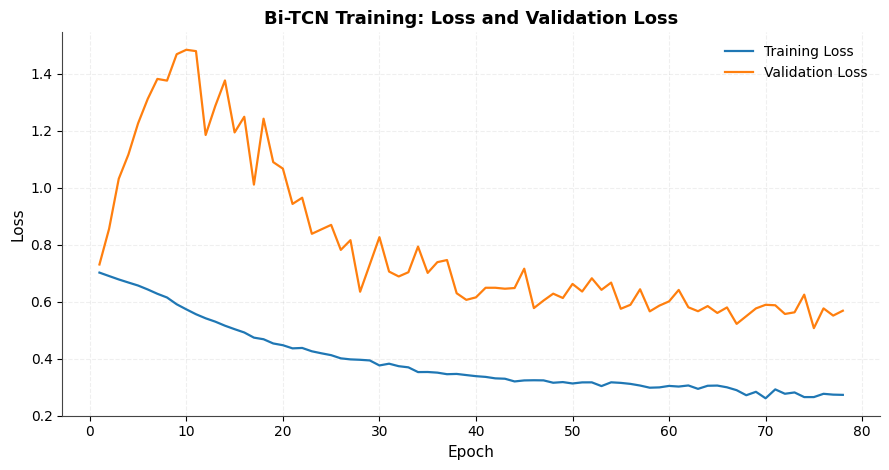

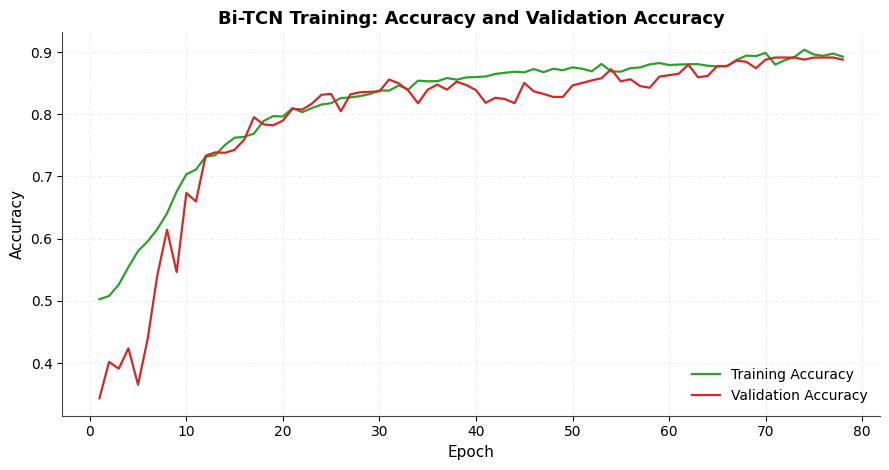

Updated visualizations saved:
 - ..\outputs\bitcn_ibm\figures\paper_loss_curves.png
 - ..\outputs\bitcn_ibm\figures\paper_accuracy_curves.png


In [5]:
# Calculate mean metrics across folds for paper-style presentation (simplified lines, no shaded bands)
all_epochs = []
all_train_loss = []
all_val_loss = []
all_train_accuracy = []
all_val_accuracy = []

for fold, hist in histories.items():
    all_epochs.append(hist["epoch"].values)
    all_train_loss.append(hist["train_loss"].values)
    all_val_loss.append(hist["val_loss"].values)
    # Some histories may not have accuracy saved under this name; fall back safely
    if "train_accuracy" in hist.columns and "val_accuracy" in hist.columns:
        all_train_accuracy.append(hist["train_accuracy"].values)
        all_val_accuracy.append(hist["val_accuracy"].values)
    else:
        # compute accuracy per epoch from stored preds if available, otherwise use NaNs
        all_train_accuracy.append(np.full(len(hist["epoch"].values), np.nan))
        all_val_accuracy.append(np.full(len(hist["epoch"].values), np.nan))

# Pad to same length and compute mean across folds
max_epochs = max(len(e) for e in all_epochs)

def pad_array(arr, max_len):
    padded = np.full(max_len, np.nan)
    padded[:len(arr)] = arr
    return padded

train_loss_padded = np.array([pad_array(loss, max_epochs) for loss in all_train_loss])
val_loss_padded = np.array([pad_array(loss, max_epochs) for loss in all_val_loss])
train_acc_padded = np.array([pad_array(acc, max_epochs) for acc in all_train_accuracy])
val_acc_padded = np.array([pad_array(acc, max_epochs) for acc in all_val_accuracy])

mean_train_loss = np.nanmean(train_loss_padded, axis=0)
mean_val_loss = np.nanmean(val_loss_padded, axis=0)

mean_train_acc = np.nanmean(train_acc_padded, axis=0)
mean_val_acc = np.nanmean(val_acc_padded, axis=0)

epochs_range = np.arange(1, max_epochs + 1)

# --- Paper-style Loss Diagram (clean lines, no shaded std bands) ---
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(epochs_range, mean_train_loss, color="#1f77b4", linewidth=1.6, label="Training Loss")
ax.plot(epochs_range, mean_val_loss, color="#ff7f0e", linewidth=1.6, label="Validation Loss")

# Styling: remove heavy outer border and keep a clean academic look
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Make spines thin and subtle
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_linewidth(0.8)
    ax.spines[spine].set_color('#444444')

# Remove top/right to match common paper style
sns.despine(ax=ax, top=True, right=True)

ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('Bi-TCN Training: Loss and Validation Loss', fontsize=13, fontweight='bold')
ax.legend(frameon=False, fontsize=10, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.2)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'paper_loss_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Paper-style Accuracy Diagram (clean lines) ---
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(epochs_range, mean_train_acc, color="#2ca02c", linewidth=1.6, label="Training Accuracy")
ax.plot(epochs_range, mean_val_acc, color="#d62728", linewidth=1.6, label="Validation Accuracy")

fig.patch.set_facecolor('white')
ax.set_facecolor('white')
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_linewidth(0.8)
    ax.spines[spine].set_color('#444444')

sns.despine(ax=ax, top=True, right=True)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Bi-TCN Training: Accuracy and Validation Accuracy', fontsize=13, fontweight='bold')
ax.legend(frameon=False, fontsize=10, loc='lower right')
ax.grid(True, linestyle='--', alpha=0.2)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'paper_accuracy_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print('Updated visualizations saved:')
print(' -', FIGURE_DIR / 'paper_loss_curves.png')
print(' -', FIGURE_DIR / 'paper_accuracy_curves.png')


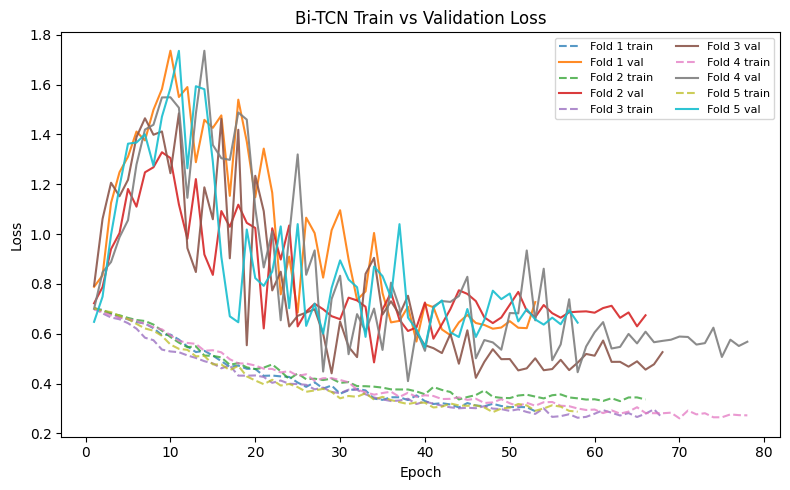

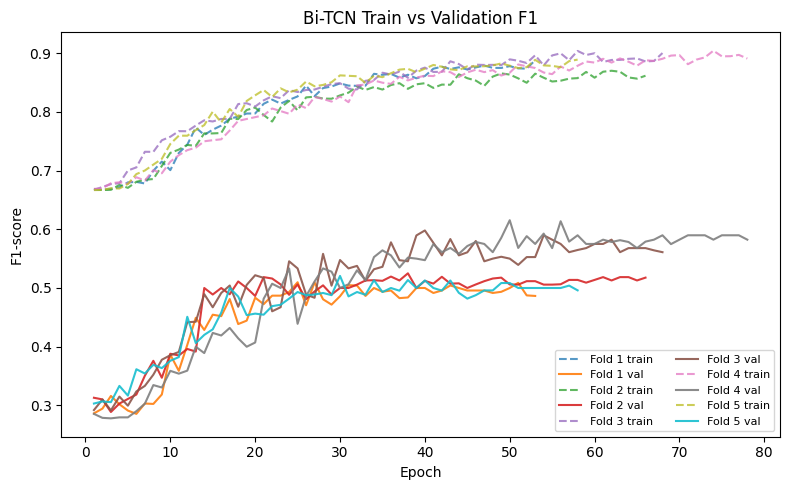

NameError: name 'y' is not defined

In [6]:
plt.figure(figsize=(8, 5))
for fold, hist in histories.items():
    plt.plot(hist["epoch"], hist["train_loss"], linestyle="--", alpha=0.75, label=f"Fold {fold} train")
    plt.plot(hist["epoch"], hist["val_loss"], alpha=0.9, label=f"Fold {fold} val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Bi-TCN Train vs Validation Loss")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "loss_curves_all_folds.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
for fold, hist in histories.items():
    plt.plot(hist["epoch"], hist["train_f1"], linestyle="--", alpha=0.75, label=f"Fold {fold} train")
    plt.plot(hist["epoch"], hist["val_f1"], alpha=0.9, label=f"Fold {fold} val")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.title("Bi-TCN Train vs Validation F1")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "f1_curves_all_folds.png", dpi=300)
plt.show()

fpr, tpr, _ = roc_curve(y, oof_probs)
precision, recall, _ = precision_recall_curve(y, oof_probs)
cm = confusion_matrix(y, (oof_probs >= global_threshold).astype(int))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].plot(fpr, tpr, label=f"ROC-AUC={oof_metrics['roc_auc']:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
axes[0].set_title("OOF ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].plot(recall, precision, label=f"PR-AUC={oof_metrics['pr_auc']:.3f}")
axes[1].set_title("OOF Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[2],
            xticklabels=["No Attrition", "Attrition"], yticklabels=["No Attrition", "Attrition"])
axes[2].set_title(f"OOF Confusion Matrix\nthreshold={global_threshold:.3f}")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "oof_evaluation_summary.png", dpi=300)
plt.show()


## 11. Paper Target Reference


In [ ]:
paper_reference = pd.DataFrame([
    {"model": "Paper Bi-TCN", "accuracy": 0.8965, "precision": 0.6981, "recall": 0.5630, "f1": 0.6161, "roc_auc": 0.7758},
    {"model": f"Our Bi-TCN CV ({best_augmentation})", **{k: oof_metrics[k] for k in ["accuracy", "precision", "recall", "f1", "roc_auc"]}},
])
metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc"]
paper_reference[[f"{c}_pct" for c in metric_cols]] = paper_reference[metric_cols] * 100
paper_reference.to_csv(OUTPUT_DIR / "paper_target_comparison.csv", index=False)
display(paper_reference)


,model,accuracy,precision,recall,f1,roc_auc,accuracy_pct,precision_pct,recall_pct,f1_pct,roc_auc_pct
0,Paper Bi-TCN,0.978300,0.959500,0.963700,0.955600,0.969400,97.830000,95.950000,96.370000,95.560000,96.940000
1,Our Bi-TCN CV (RandomOverSampling),0.852381,0.544248,0.518987,0.531317,0.792938,85.238095,54.424779,51.898734,53.131749,79.293754


## 12. Compare Against Baselines


In [38]:
baseline_candidates = [
    PROJECT_ROOT / "outputs" / "baseline_results.csv",
    PROJECT_ROOT / "outputs" / "baselines" / "baseline_results.csv",
    PROJECT_ROOT / "results" / "baseline_results.csv",
]

baseline_path = next((p for p in baseline_candidates if p.exists()), None)
bitcn_row = {
    "model": "Bi-TCN IBM",
    "accuracy": oof_metrics["accuracy"],
    "precision": oof_metrics["precision"],
    "recall": oof_metrics["recall"],
    "f1": oof_metrics["f1"],
    "roc_auc": oof_metrics["roc_auc"],
    "pr_auc": oof_metrics["pr_auc"],
}

if baseline_path is not None:
    baseline_df = pd.read_csv(baseline_path)
    comparison_df = pd.concat([baseline_df, pd.DataFrame([bitcn_row])], ignore_index=True)
else:
    print("No baseline_results.csv found. Exporting Bi-TCN-only comparison table.")
    comparison_df = pd.DataFrame([bitcn_row])

comparison_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
display(comparison_df)


No baseline_results.csv found. Exporting Bi-TCN-only comparison table.


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Bi-TCN IBM,0.852381,0.544248,0.518987,0.531317,0.792938,0.529019


## 13. Output Files


In [39]:
print("Saved artifacts:")
for path in [
    OUTPUT_DIR / "config.json",
    OUTPUT_DIR / "fold_results.csv",
    OUTPUT_DIR / "metrics_summary.csv",
    OUTPUT_DIR / "augmentation_comparison.csv",
    OUTPUT_DIR / "oof_metrics.json",
    OUTPUT_DIR / "model_comparison.csv",
    OUTPUT_DIR / "paper_target_comparison.csv",
    FIGURE_DIR / "loss_curves_all_folds.png",
    FIGURE_DIR / "f1_curves_all_folds.png",
    FIGURE_DIR / "oof_evaluation_summary.png",
]:
    print("-", path)

print("\nBest fold checkpoints:")
for path in sorted(MODEL_DIR.glob("*_best_model_fold_*.pth")):
    print("-", path)


Saved artifacts:
- F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\outputs\bitcn_ibm\config.json
- F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\outputs\bitcn_ibm\fold_results.csv
- F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\outputs\bitcn_ibm\metrics_summary.csv
- F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\outputs\bitcn_ibm\augmentation_comparison.csv
- F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\outputs\bitcn_ibm\oof_metrics.json
- F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\outputs\bitcn_ibm\model_comparison.csv
- F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\outputs\bitcn_ibm\paper_target_comparison.csv
- F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\outputs\bitcn_ibm\figures\loss_curves_all_folds.png
- F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\outputs\bitcn_ibm\figures\f1_curves_all_folds.png
- F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\ou